 XGBoost Accuracy: 0.6170


 Confusion Matrix:


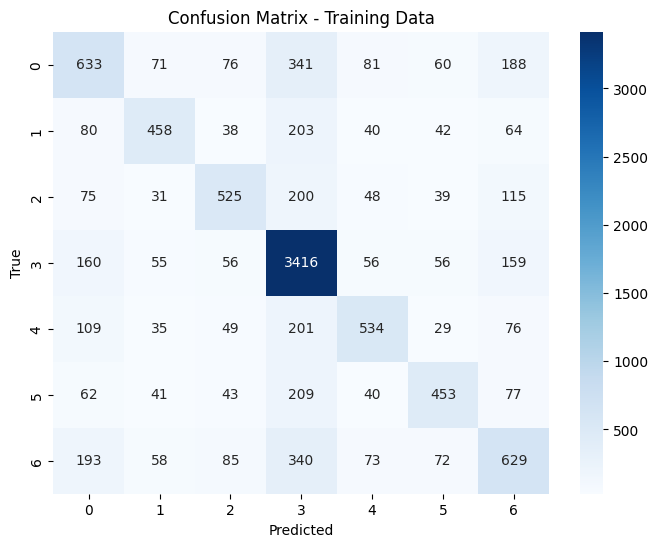

In [13]:
# Import libraries
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

# Prepare data
X_train = train_df[[f"p{i}" for i in range(1, 43)] + ["turn"]]
y_train = train_df["label_move_col"]

X_val = val_df[[f"p{i}" for i in range(1, 43)] + ["turn"]]
y_val = val_df["label_move_col"]

X_test = test_df[[f"p{i}" for i in range(1, 43)] + ["turn"]]

# Convert to numeric safely
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype("int")
y_train = pd.to_numeric(y_train, errors='coerce').fillna(0).astype("int")
X_val = X_val.apply(pd.to_numeric, errors='coerce').fillna(0).astype("int")
y_val = pd.to_numeric(y_val, errors='coerce').fillna(0).astype("int")
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype("int")

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    learning_rate=0.1,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_val)

# Results
xgb_accuracy = accuracy_score(y_val, xgb_pred)
xgb_cm = confusion_matrix(y_val, xgb_pred)

print(f" XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"\n\n Confusion Matrix:")


plt.figure(figsize=(8,6))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Training Data")
plt.show()

In [14]:
# predict on test data
y_test_pred = xgb_model.predict_proba(X_test).argmax(axis=1).astype(int)
# y_test_pred = np.argmax(y_test_pred , axis=1).astype(int)
Prediction = pd.DataFrame({"id": range( 1 , len(y_test_pred) +1 ), "label_move_col" : y_test_pred })
Prediction.to_csv("XGboost_prediction.csv" , index = False)